In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import deque
import scipy.stats as stats

# Проект: ветвящиеся процессы

## Постановка задачи: 
Придумать и реализовать критерий проверки того, что текст является ветвящимся процессом. В дальнейшем пришли к выводу, что структура текста скорее вевящийся процесс в изменяющейся среде - добавили криерий отличающий постоянную среду от изменяющейся.

### Основные этапы
- генерация дерева: как ветвящйся процесс, так и неслучайные или зависимые деревья
- генерация ветвящегося процесса в случайной среде
- получение основных характеристик ветвящегося процесса
- реализация критериев (на основе критерия Стъюдента)
- визуализация ветвящегося процесса (бета-версия)


### Генератор дерева

In [ ]:
def generate_tree(generator, dist_params = None, max_generations =6, **kwargs):
    graph = nx.DiGraph()
    graph.clear()

    if isinstance(generator, str):
        def dist_generator(dist_params, graph =None, node=None, **kwargs):
            dist_func = getattr(np.random, generator)
            return max(1, dist_func(**dist_params))
        generator_func = dist_generator
    else:
        generator_func = generator

    generation_counters = {}
    dist_params = dist_params or {}

    node_id = (1,1)
    num_children = generator_func(dist_params, graph = graph, node = node_id, **kwargs)
    graph.add_node(node_for_adding=node_id,
                        generation = 1,
                        children_count= num_children)

    queue = deque([(node_id)])
    generation_counters[1] = 1

    while queue:
      cur_node = queue.popleft()
      cur_gen = graph.nodes[cur_node]["generation"]
      num_children = graph.nodes[cur_node]['children_count']

      if cur_gen > max_generations:
        continue
      next_gen = cur_gen + 1
      if next_gen not in generation_counters:
        generation_counters[next_gen] = 0



      for child_num in range(1, num_children + 1):
        generation_counters[next_gen] += 1
        child_id = (next_gen, generation_counters[next_gen])

        child_children_count = 0
        graph.add_node(node_for_adding = child_id,
                            generation = next_gen,
                            children_count = child_children_count)
        graph.add_edge(cur_node, child_id)

        child_children_count  = generator_func(dist_params, graph = graph, node = child_id, **kwargs)
        graph.nodes[child_id]['children_count'] = child_children_count


        if next_gen<max_generations:
          queue.append((child_id))


    return graph

In [ ]:
def generate_tree_random_envi(generator= 'geometric', dist_params = None, max_generations =6, **kwargs):
    graph = nx.DiGraph()
    graph.clear()

    if isinstance(generator, str):
        def dist_generator(dist_params, graph =None, node=None, **kwargs):
            dist_func = getattr(np.random, generator)
            return max(1, dist_func(dist_params))
        generator_func = dist_generator
    else:
        generator_func = generator

    generation_counters = {}
    dist_params = dist_params or {}
    generation_params= {}

    node_id = (1,1)
    generation_params[1] = generate_envi()
    num_children = generator_func(generation_params[1], graph = graph, node = node_id, **kwargs)
    graph.add_node(node_for_adding=node_id,
                        generation = 1,
                        children_count= num_children)

    queue = deque([(node_id)])
    generation_counters[1] = 1

    while queue:
      cur_node = queue.popleft()
      cur_gen = graph.nodes[cur_node]["generation"]
      num_children = graph.nodes[cur_node]['children_count']

      if cur_gen > max_generations:
        continue
      next_gen = cur_gen + 1
      if next_gen not in generation_counters:
        generation_counters[next_gen] = 0
      if next_gen not in generation_params:
        generation_params[next_gen] = generate_envi()



      for child_num in range(1, num_children + 1):
        generation_counters[next_gen] += 1
        child_id = (next_gen, generation_counters[next_gen])

        child_children_count = 0
        graph.add_node(node_for_adding = child_id,
                            generation = next_gen,
                            children_count = child_children_count)
        graph.add_edge(cur_node, child_id)

        child_children_count  = generator_func(generation_params[next_gen], graph = graph, node = child_id, **kwargs)
        graph.nodes[child_id]['children_count'] = child_children_count
        #print(f"Added node {child_id}: gen_param = {generation_params[next_gen]}")

        if next_gen<max_generations:
          queue.append((child_id))

    graph.generation_params = generation_params
    return graph

In [ ]:
# geom in random environment

def generate_tree_RE(max_generations =6):
    graph = nx.DiGraph()
    graph.clear()

    generation_counters = {}
    generation_parameters = {}
    generation_parameters[1] = generate_envi()


    node_id = (1,1)
    num_children = np.random.poisson(generation_parameters[1])
    graph.add_node(node_for_adding=node_id,
                        generation = 1,
                        children_count= num_children)

    queue = deque([(node_id)])
    generation_counters[1] = 1

    while queue:
      cur_node = queue.popleft()
      cur_gen = graph.nodes[cur_node]["generation"]
      num_children = graph.nodes[cur_node]['children_count']

      if cur_gen > max_generations:
        continue
      next_gen = cur_gen + 1
      if next_gen not in generation_counters:
        generation_counters[next_gen] = 0
      if next_gen in generation_parameters:
        p = generation_parameters[next_gen]
      else:
        p = generate_envi()
        generation_parameters[next_gen] = p


      for child_num in range(1, num_children + 1):
        generation_counters[next_gen] += 1
        child_id = (next_gen, generation_counters[next_gen])

        child_children_count = 0
        graph.add_node(node_for_adding = child_id,
                            generation = next_gen,
                            children_count = child_children_count)
        graph.add_edge(cur_node, child_id)

        if next_gen == 2:
          child_children_count  = max(2, np.random.poisson(p))
        else:
          child_children_count  =  np.random.poisson(p)
        graph.nodes[child_id]['children_count'] = child_children_count


        if next_gen<max_generations:
          queue.append((child_id))


    return graph

In [ ]:
#CUSTOM GENERATORS

def parameter_generation(dist_params, graph = None, node = None, **kwargs):
    generation = node[0]
    base_p = dist_params.get('p', 0.5)
    dist = dist_params.get('dist', 'geometric')
    dist_func = getattr(np.random, dist)
    p = base_p*(0.9 ** (generation - 1))
    return max(1, dist_func(p))

def even_repeat(dist_params, graph = None, node = None, **kwargs):
    generation = node[0]
    if(generation % 2 == 0):
        parent = list(graph.predecessors(node))[0]
        return graph.nodes[parent]['children_count']
    dist = dist_params.get('dist')
    dist_params_copy = dist_params.copy()

    del dist_params_copy['dist']
    dist_func = getattr(np.random, dist)
    return max(1, dist_func(**dist_params_copy))

#random environment



def geom_random_envi(dist_params, graph = None, node = None, **kwargs):
  generation = node[0]
  if 'random_envi' in kwargs:
    if generation in kwargs['random_envi']:
      p = kwargs['random_envi'][generation]
    else:
      p = generate_envi()
      kwargs['random_envi'][generation] = p
  else:
    kwargs['random_envi'] = {}
    p = generate_envi()
    kwargs['random_envi'][generation] = p
  return max(1, np.random.geometric(p))



In [ ]:
def get_max_generation(graph):
  res = 0
  for n in graph:
    gen = graph.nodes[n]['generation']
    if gen>res:
      res = gen
  return res

In [ ]:
def get_generation(graph, num_generation):
  res = []
  for n in graph:
    if graph.nodes[n]['generation'] == num_generation:
      res.append(graph.nodes[n]['children_count'])
  return res

In [ ]:
def generation_stat(graph):
  gen_dict = {}
  for n in graph:
    gen = graph.nodes[n]['generation']

    if gen not in gen_dict:
      gen_dict[gen] = []
    gen_dict[gen].append(graph.nodes[n]['children_count'])
  return gen_dict

In [ ]:
def generation_var(graph, ignore = 0): #дисперсия средних поколений
  #ignore = количество поколений сначала, которые мы пропускаем
  depth = get_max_generation(graph)
  generation_means = [0]*depth
  for i in range(ignore, depth):
    generation_means[i] = np.mean(get_generation(graph, i+1))
  return np.var(generation_means)

In [ ]:
def print_process(graph):
    for n in graph:
        print(n, graph.nodes[n]['children_count'])

In [ ]:
def get_siblings(graph):
    depth = get_max_generation(graph)
    d= {} #list of lists
    for n in graph:
        n_children = graph.successors(n)
        n_vals = []
        for i in n_children:
            n_vals.append(graph.nodes[i]['children_count'])
        if n[0] != depth:
            d[n] = n_vals
    return d

In [ ]:
def get_subtrees(graph, generation = None):
    depth = get_max_generation(graph)
    subtrees = {}
    if generation == None:
      for n in graph:
          if n[0] != depth:
              n_desc = nx.descendants(graph, n)
              n_val = []
              for i in n_desc:
                  n_val.append(graph.nodes[i]['children_count'])
              subtrees[n] = n_val
    else:
      for n in graph:
        if n[0] == generation:
          n_desc = nx.descendants(graph, n)
          n_val = []
          for i in n_desc:
              n_val.append(graph.nodes[i]['children_count'])
          subtrees[n] = n_val

    return subtrees



In [ ]:
def get_moments(mass, max_moment = 2):
  # выборка -> список моментов (1 ... max_moment), т.е. EX, EX^2,... EX^(max)
  # дисперсии тут нет!
  # я добавила нулевой момент (=0), чтобы удобно вызывать моменты по их номеру,
  # т.е. moments[2] будет возвращать второй момент
  n = len(mass)
  moments = [0]
  for i in range(1, max_moment + 1):
    sum = 0
    for j in range(n):
      sum += mass[j]**i
    moments.append(sum/n)
  return moments





In [ ]:
def criterion_mixed(graph, max_moment = 2):
  depth = get_max_generation(graph)
  chapters = graph.nodes[(1,1)]['children_count']
  if chapters < 2:
    print("tufta")
    return
  res = []
  #попарное сравнение глав
  for ch1 in range(1, chapters+1):
    for ch2 in range(ch1+1, chapters+1):
      subtree1 = nx.descendants(graph, (2,ch1))
      subtree2 = nx.descendants(graph, (2,ch2))
      for i in range(depth, 2, -1): #поднимаемся по поколениям
        sum1 = []
        sum2 = []
        for j in subtree1:
          if j[0] == i:
            sum1.append(graph.nodes[j]['children_count'])
        for j in subtree2:
          if j[0] == i:
            sum2.append(graph.nodes[j]['children_count'])
        #print(f"{ch1} vs {ch2}, gen {i}: {np.abs(np.mean(sum1) - np.mean(sum2))}")
        res.append(np.abs(np.mean(sum1) - np.mean(sum2)))
  #plt.plot(res, color = 'green')


In [ ]:
def criterion_matrix(graph,color = 'lightpink', max_monment = 2):
  depth = get_max_generation(graph)
  chapters = graph.nodes[(1,1)]['children_count']
  if chapters < 2:
    #print("tufta, a ne text")
    return 'tufta'
  res = []
  for ch in range(1, chapters+1):
    subtree = nx.descendants(graph, (2,ch))
    subtree_res = []
    for i in range(depth, 2, -1): #поднимаемся по поколениям
      sum = []
      for j in subtree:
        if j[0] == i:
          sum.append(graph.nodes[j]['children_count'])
      subtree_res.append(np.mean(sum))
    res.append(subtree_res)

  diff=[]
  for gen in range(0, 4):
    diff_gen = []
    for i in range(0, chapters):
      for j in range(i+1, chapters):
        diff_gen.append(res[i][gen] - res[j][gen])
    diff.append(np.abs(np.mean(diff_gen)))


 # plt.plot(diff, color = color)
  return max(diff)




In [ ]:
#отличать гальтона ватсона от изменяющейся среды

def criterion_matrix_gw(graph,color = 'lightpink', max_monment = 2):
  depth = get_max_generation(graph)
  chapters = graph.nodes[(1,1)]['children_count']
  if chapters < 2:
    #print("tufta, a ne text")
    return 'tufta'

  res = []
  for ch in range(1, chapters+1):
    subtree = nx.descendants(graph, (2,ch))
    subtree_res = []
    for i in range(depth, depth-2, -1): #поднимаемся по поколениям
      sum = []
      for j in subtree:
        if j[0] == i:
          sum.append(graph.nodes[j]['children_count'])#ашли сумму
      subtree_res.append(np.mean(sum)) #СРЕДНЕЕ
    res.append(np.abs(subtree_res[0] - subtree_res[1]))#res[0] = [means of 1st subtree, lowest generation]
  return max(res)


def criterion_gw_means(graph): #without subtree division
  depth = get_max_generation(graph)
  chapters = graph.nodes[(1,1)]['children_count']
  means = {}
  diff = []
  res=  0
  if chapters < 2:
    #print("tufta, a ne text")
    return 'tufta'
  for i in range(depth, 3, -1):
    means[i] = np.mean(get_generation(graph, i))
    #print(means[i], get_generation(graph, i))
  for i in range(depth, 4, -1):
    diff.append(np.abs(means[i] - means[i-1]))
    #print(diff[i])
  return max(diff)



In [ ]:
def generate_envi():
  #return np.random.beta(1, 3)*0.8 + 0.1 #БЕТА НА 0.1 0.9
  return np.random.uniform(1, 5)

In [ ]:
def cov(x, y):
  len_x = len(x)
  len_y = len(y)
  n = min(len_x, len_y) #выборки одной длины - обрезаем
  x_sum = 0
  y_sum = 0
  xy_sum = 0
  for i in range(n):
    x_sum+=x[i]
    y_sum += y[i]
    xy_sum += x[i]*y[i]
  return xy_sum/n - (x_sum*y_sum)/(n**2)


In [ ]:
def corr(x, y):
  len_x = len(x)
  len_y = len(y)
  n = min(len_x, len_y)
  return cov(x, y)/np.sqrt(np.var(x[:n]) * np.var(y[:n]))

# Визуализация ветвящегося процесса

In [ ]:
!apt install libgraphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 41 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2

In [ ]:
def plot_branching_tree(G: nx.DiGraph, title: str = "Ветвящийся процесс",with_labels = True, node_color= 'lightpink', edge_color = 'salmon'):
    """
    Визуализирует ориентированное дерево.

    Args:
        G: ориентированное дерево
        title: заголовок графика
    """
    plt.figure(figsize=(12, 8))

    # Используем древовидную layout для лучшей визуализации
    pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    labels = {node: data['children_count'] for node, data in G.nodes(data=True)}

    # Рисуем граф
    nx.draw(
        G, pos,
        with_labels=with_labels,
        labels = labels,
        node_size=500,
        node_color=node_color,
        font_size=15,
        font_weight='bold',
        arrows=True,
        arrowsize=25,
        edge_color = edge_color,
        width=3
    )

    #plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
def subtree_gen(graph, generation, subtree_root = 2):
  # default берем поддеревья - главы
  n = graph.nodes[(1,1)]['children_count']
  return n


subtree_gen(process, 1)

3

# Дополнительно
Моделировние вымирания ветвящегося процесса


<>:33: SyntaxWarning: invalid escape sequence '\ '
<>:33: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-604741086.py:33: SyntaxWarning: invalid escape sequence '\ '
  plt.title(f'{c} \ {k} populations went extinct')


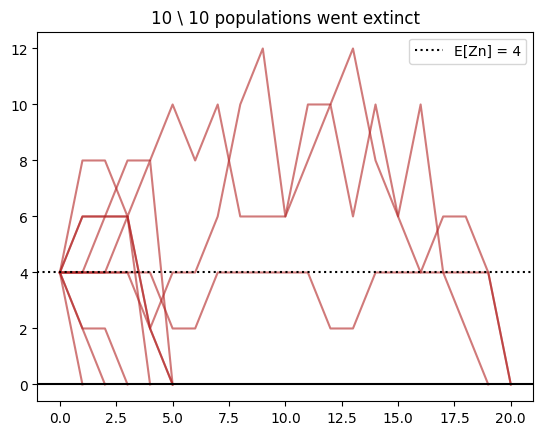

In [ ]:
def dying_out(dist_params, graph = None, node = None, **kwargs):
  i = stats.binom.rvs(1, p = 0.5)
  if i == 0:
    return 0
  return 2
  #return stats.poisson.rvs(1)

zn = []
c = 0
k = 10
maxg = 20
for i in range(k):
  process1 = generate_tree(dying_out, max_generations = maxg)
  process2 = generate_tree(dying_out, max_generations = maxg)
  process3 = generate_tree(dying_out, max_generations = maxg)
  process4 = generate_tree(dying_out, max_generations = maxg)
  depth = max(get_max_generation(process1),get_max_generation(process2), get_max_generation(process3), get_max_generation(process4))
  zn.append([])

  for n in range(1, depth+1):
    genn1 = get_generation(process1, n)
    genn2 = get_generation(process2, n)
    genn3 = get_generation(process3, n)
    genn4 = get_generation(process4, n)
    zn[i].append(len(genn1) + len(genn2) + len(genn3) + len(genn4))
  if depth < 30:
    zn[i].append(0)
    plt.plot(zn[i], color = 'firebrick', alpha = 0.6)
    c+=1
  else:
    plt.plot(zn[i], color = 'green', alpha = 0.6 )
plt.axhline(y=4, color="black", linestyle=':', label = 'E[Zn] = 4')
plt.axhline(y=0, color = 'black')
plt.title(f'{c} \ {k} populations went extinct')
plt.legend()


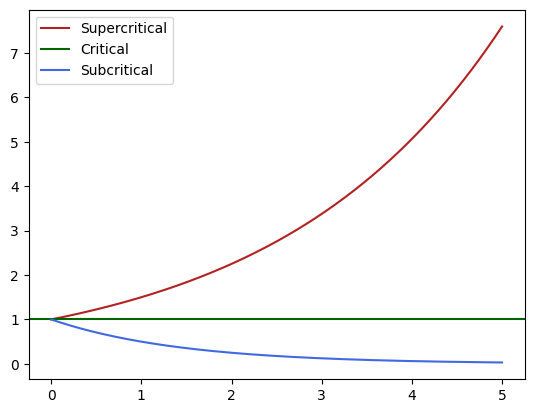

In [ ]:
x = np.linspace(0, 5, 1000)
plt.plot(x, (3/2)**x, color = 'firebrick', label ='Supercritical')
plt.axhline(y= 1, color = 'darkgreen', label = 'Critical')
plt.plot(x, (1/2)**x, color = 'royalblue', label = 'Subcritical')
plt.legend()